# Часть 2

# 2.1 T-распределение

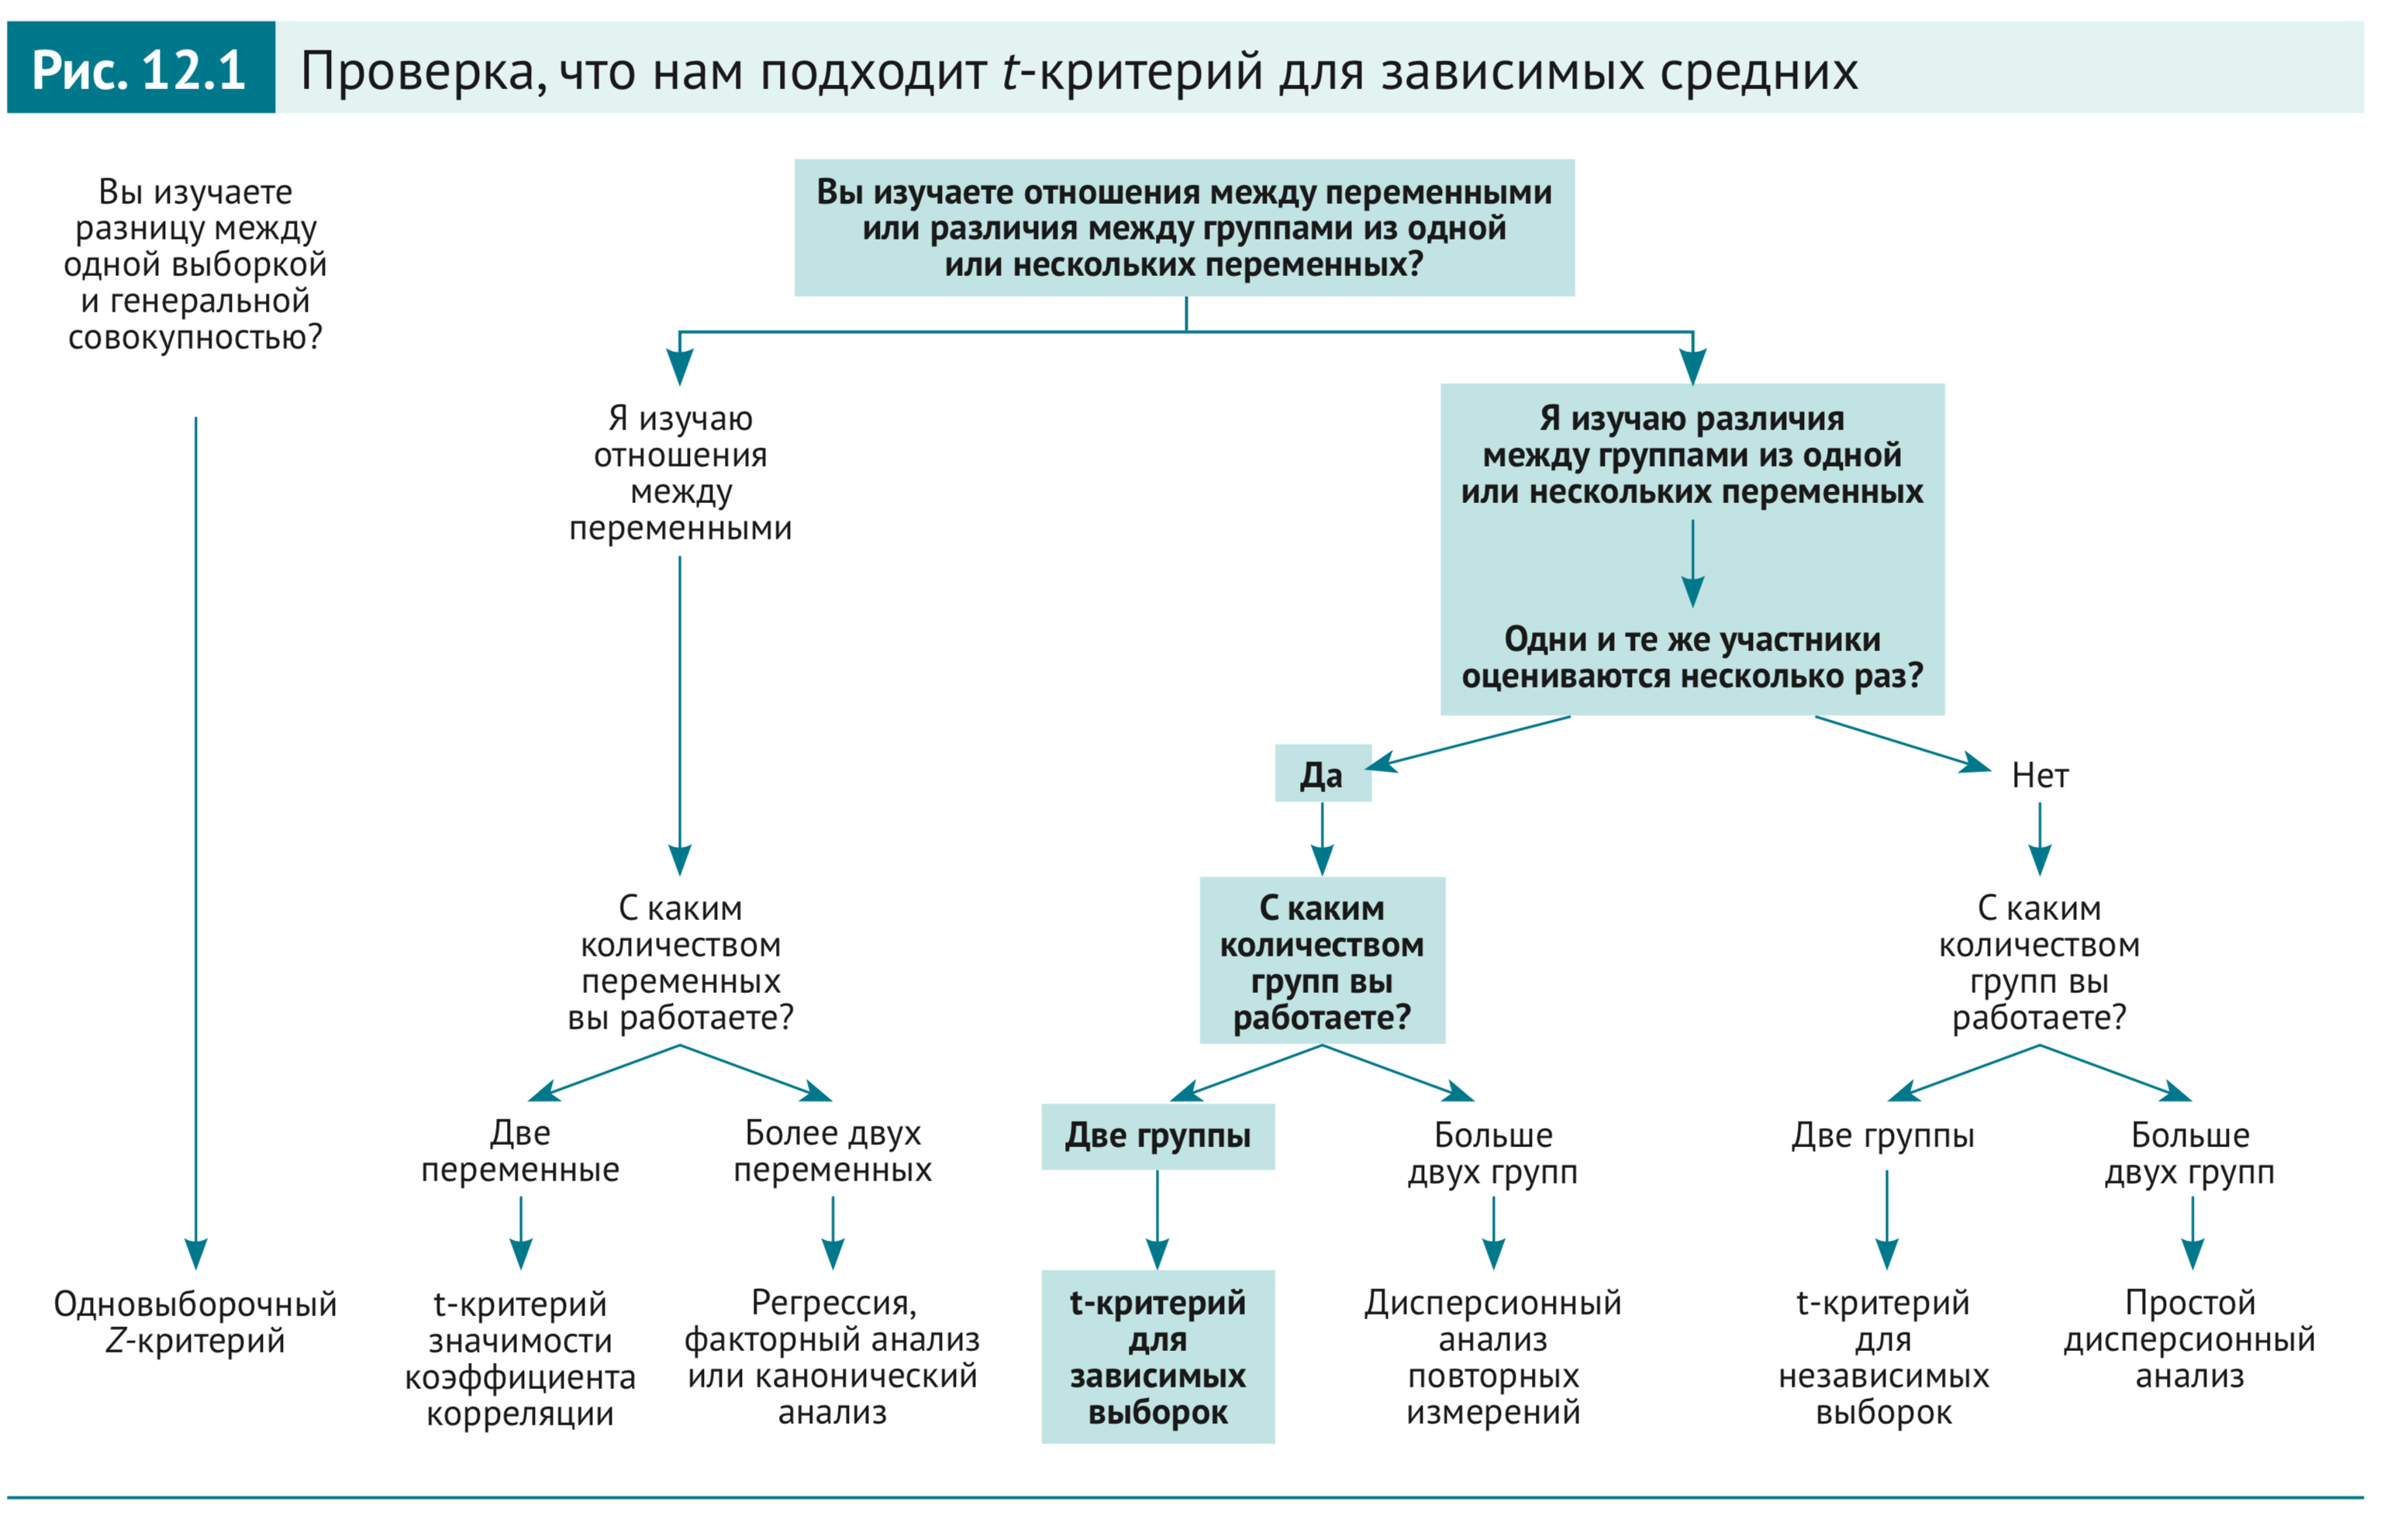

`Распределение Стьюдента` (*t-distribution*) по сути представляет собой сумму нескольких нормально распределенных случайных величин. Чем больше величин, тем больше верятность, что их сумма будет иметь нормальное распределение.  
Таким образом, количество суммируемых величин определяет важнейший параметр формы данного распредения - число степеней свободы (*degrees of freedom* $df=n-1$).

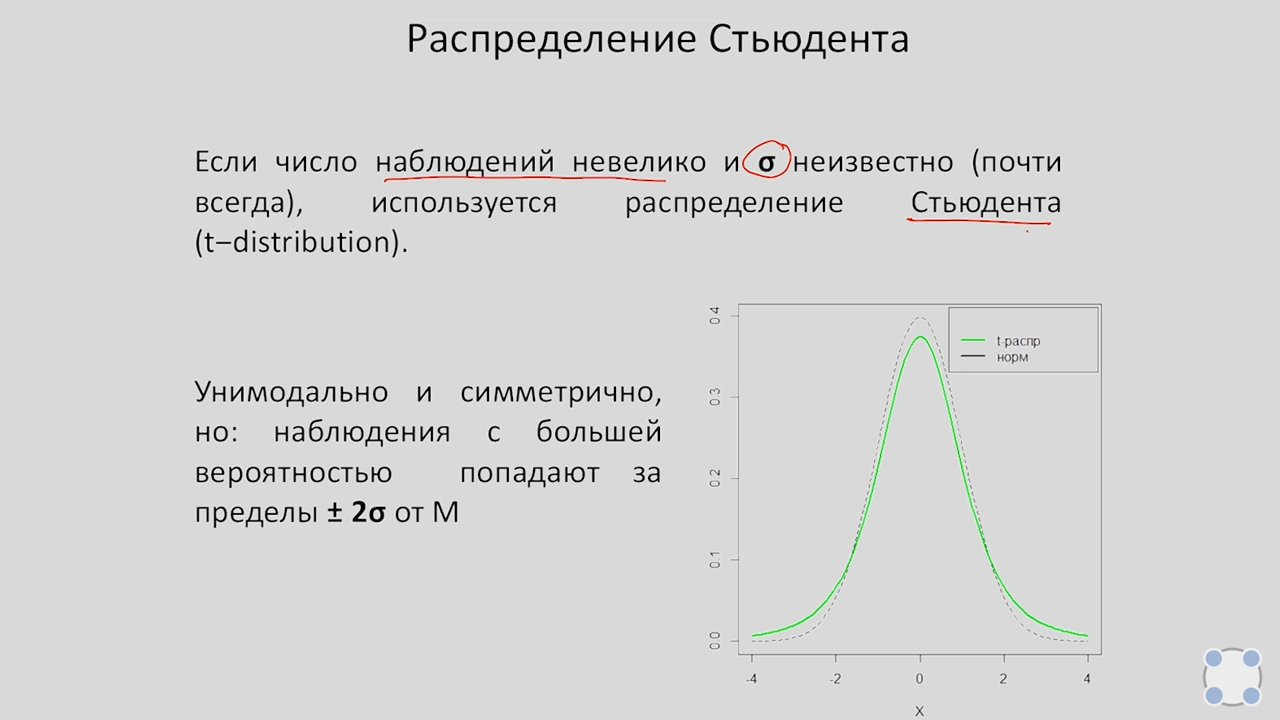

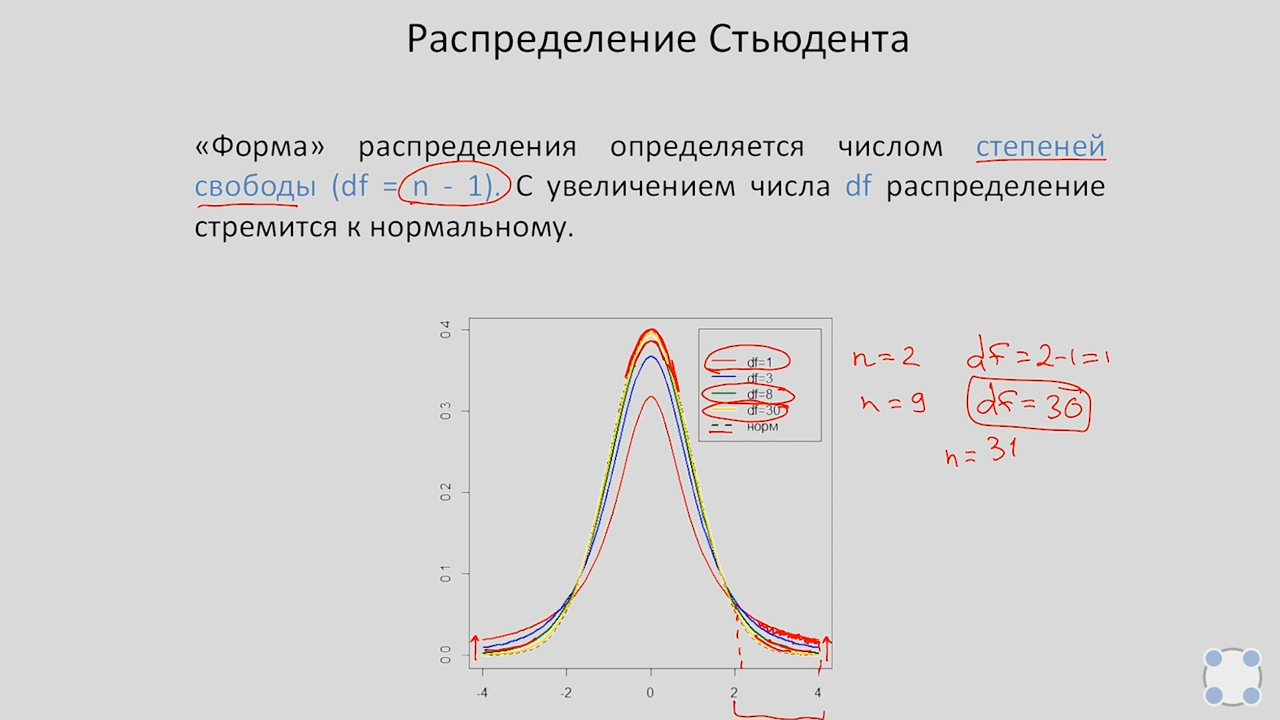

In [14]:
from scipy import stats 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

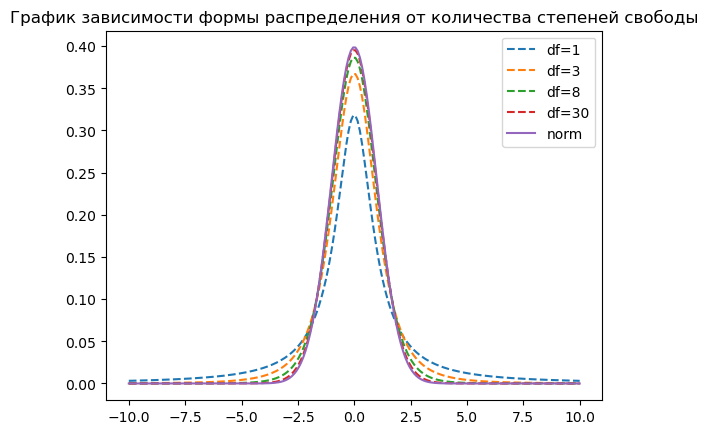

In [9]:
"""Зависимость формы распределения при увеличении количества степеней свободы."""
x = np.linspace(-10, 10, 200)
# Чем больше степеней свободы, тем ближе распределение к нормальному
# pdf - Функция плотности вероятности
# cdf - Кумулятивная функция распределения
y1 = stats.t.pdf(x, df=1) # 2 наблюдения
y2 = stats.t.pdf(x, df=3) # 4 наблюдения
y3 = stats.t.pdf(x, df=8) # 9 наблюдений
y4 = stats.t.pdf(x, df=30) # 31 наблюдение
y5 = stats.norm.pdf(x)       # нормальное распределение

plt.title('График зависимости формы распределения от количества степеней свободы')
plt.plot(x, y1, '--')
plt.plot(x, y2, '--')
plt.plot(x, y3, '--')
plt.plot(x, y4, '--')
plt.plot(x, y5)
plt.legend(('df=1', 'df=3', 'df=8', 'df=30', 'norm'))
plt.show()

График плотности распределения Стьюдента, как и нормального распределения, является симметричным и имеет вид колокола, но с более «тяжёлыми» хвостами.

## Очень важный шаг

В видео лекциях я сказал, что мы используем t - распределение в ситуации небольшого объема выборки. Необходимо более подробно пояснить, зачем это нужно.

Вернемся к предельной центральной теореме, мы уже узнали, что если некий признак в генеральной совокупности распределен нормально ([не обязательно](https://stepik.org/lesson/8077/step/7?unit=1357)) со средним $\mu$ и стандартным отклонением $\sigma$, и мы будем многократно извлекать выборки одинакового размера $n$, и для каждой выборки рассчитывать, как далеко выборочное среднее $\bar{X}$ отклонилось от среднего в генеральной совокупности в единицах стандартной ошибки среднего:

$$\large z = \frac{\bar{X} - \mu}{\frac{\sigma}{\sqrt{n}}}$$

то эта величина $\large z$ будет иметь стандартное нормальное распределение со средним равным нулю и стандартным отклонением равным единице.

Обратите внимание, что для расчета стандартной ошибки мы используем именно стандартное отклонение в генеральной совокупности - $\sigma$. Ранее мы уже обсуждали, что на практике $\sigma$ нам практически никогда не известна, и для расчета стандартной ошибки мы используем выборочное стандартное отклонение.

Так вот, строго говоря в таком случае распределение отклонения выборочного среднего и среднего в генеральной совокупности, деленного на стандартную ошибку, теперь будет описываться именно при помощи t - распределения:

$$\large t = \frac{\bar{X} - \mu}{\frac{sd}{\sqrt{n}}}$$

таким образом, в случае неизвестной $\sigma$ мы **всегда будем иметь дело с t - распределением.**  

На этом этапе вы должны с негодованием спросить меня: почему же мы применяли z - критерий в первом модуле курса, для проверки гипотез, используя выборочное стандартное отклонение?

Мы уже знаем, что при довольно большом объеме выборки (обычно в учебниках приводится правило, $n > 30$) t - распределение совсем близко подбирается к нормальному распределению:

Поэтому иногда, для простоты расчетов говорится, что если n > 30, то мы будем использовать свойства нормального распределения для наших целей. Строго говоря, это конечно неправильный подход, который часто критикуют. В до компьютерную эпоху этому было некоторое объяснение, чтобы не рассчитывать для каждого n больше 30 соответствующее критическое значение t - распределения, статистики как бы округляли результат и использовали нормальное распределение для этих целей. Сегодня, конечно, с этим больше никаких проблем нет, и все статистические программы, разумеется, без труда рассчитают все необходимые показатели для t - распределения с любым числом степеней свободы. Действительно при выборках очень большого объема t - распределение практически не будет отличаться от нормального, однако, хоть и очень малые но различия все равно будут.

Поэтому, правильнее будет сказать, что мы используем t - распределение не потому что у нас маленькие выборки, а потому что мы не знаем стандартное отклонение в генеральной совокупности.

Поэтому в дальнейшем мы всегда будем использовать t - распределение для проверки гипотез, если нам неизвестно стандартное отклонение в генеральной совокупности, необходимое для расчета стандартной ошибки, даже если объем выборки больше 30.

Дополнительные тезисы:

- **Использование t-распределения уменьшает вероятность совершить ошибку первого рода, то есть отклонить нулевую гипотезу, когда она верна.**

- **Число степеней свободы — это разность числа наблюдений и числа оцененных параметров.**

[Пост](https://habr.com/ru/company/stepic/blog/311354/) на Habr-е о степенях свободы.

### Примеры

In [14]:
"""Работа с нормальным распределением - отклоняется H0"""
M = 10            # Среднее ГС
x_mean = 10.8     # среднее выборки
sd = 2            # стандартное отклонение выборки
N = 25            # кол-во наблюдений в выборке

# стандартная ошибка среднего по ЦПТ
se = sd / N**0.5  # se = 0.4

# рассчет насколько x_mean отклонилось от M в единицах стандартного отклонения
z = (x_mean - M) / se # z = 2 - Отклонение на 2 вправо

# рассчет p-уровня значимости
# stats.norm.cdf рассчитывает площадь под нормального распределения до значения z.
p = 2*(1-stats.norm.cdf(z)) # p = 0.455...
# в таком случае можно отклонить H0 т.к. p < 0,05
print("Вероятность получить z=2 в обе стороны(p) =", round(p*100, 2), "%")
if p < 0.05:
    print('p =', p, ', отклоняем нулевую гипотезу , т.к. p < 0,05')
else:
    print('p =', p, ', принимаем нулевую гипотезу, т.к. p > 0,05')

Вероятность получить z=2 в обе стороны(p) = 4.55 %
p = 0.045500263896358195 , отклоняем нулевую гипотезу , т.к. p < 0,05


In [15]:
2*stats.norm.cdf(-2)

0.04550026389635839

In [16]:
"""Та же выборка, работа с t-распределением - H0 не отклоняется"""
M = 10            # Среднее ГС
x_mean = 10.8     # среднее выборки
sd = 2            # стандартное отклонение
N = 25            # кол-во наблюдений
df = N - 1        # степень свободы

# se = sd / (df)**0.5  # se = 0.4

# рассчет насколько x_mean отклонилось от M в единицах стандартного отклонения
t = 2 # предполагается, что t = z из шага выше.

# рассчет p-уровня значимости
# stats.t.cdf рассчитывает площадь под кривой t-распределения до значения t.
p = 2*(1-stats.t.cdf(t, df)) # p = 0.569...
# в этом случае отклонить H0 уже нельзя т.к. p > 0,05
print("Вероятность получить z=2 в обе стороны(p) =", round(p*100, 2), "%")
if p < 0.05:
    print('p =', p, ', отклоняем нулевую гипотезу , т.к. p < 0,05')
else:
    print('p =', p, ', нулевую гипотезу отклонить нельзя, т.к. p > 0,05')

Вероятность получить z=2 в обе стороны(p) = 5.69 %
p = 0.056939849936591624 , нулевую гипотезу отклонить нельзя, т.к. p > 0,05


### Пример

Если на выборке в 15 наблюдений при помощи одновыборочного t-теста проверяется нулевая гипотеза: 
μ=10 

и рассчитанное t-значение равняется -2 (t = -2), то p-уровень значимости  (двусторонний) ﻿ равен:

In [19]:
p = stats.t.cdf(-2, df=14)
p # считает в одну сторону, поэтому умножаем на 2

0.03264397644455599

In [20]:
round(p*2*100, 2)

6.53

# 2.2 Сравнение двух средних; t-критерий Стьюдента

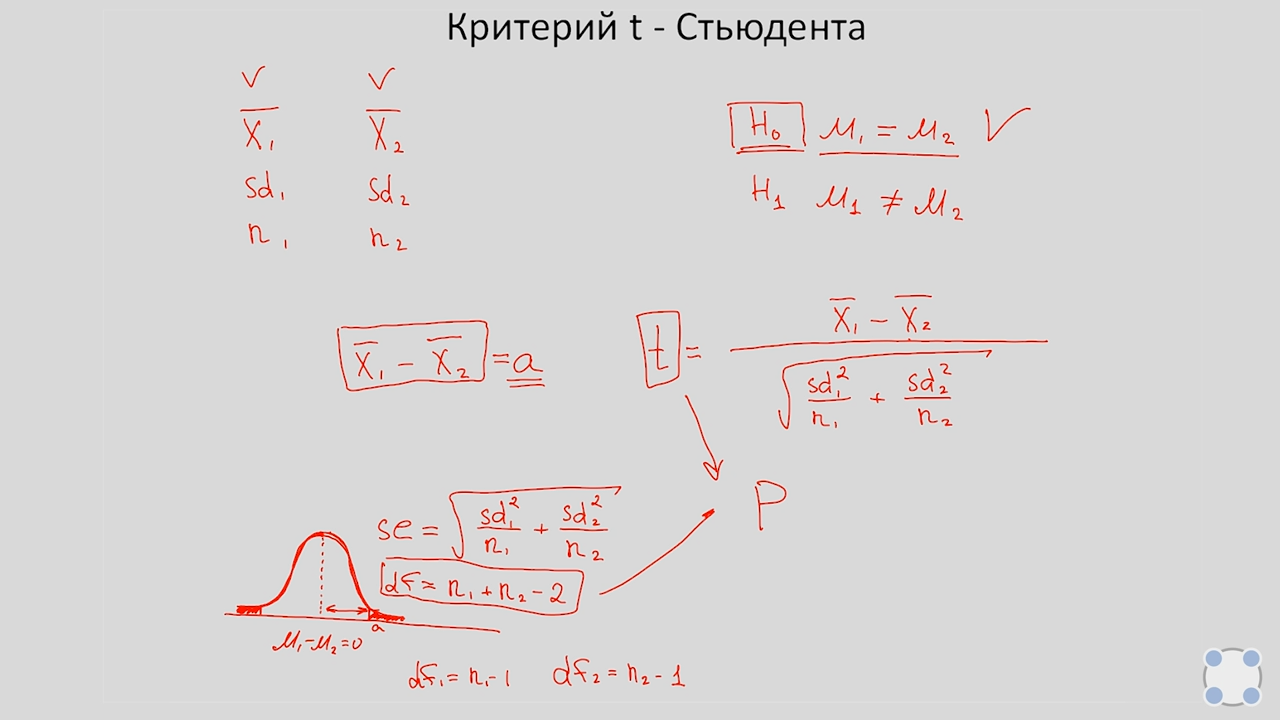

`t-критерий Стьюдента` — общее название для статистических тестов, в которых статистика критерия имеет распределение Стьюдента. Наиболее часто t-критерии применяются для проверки равенства средних значений в двух выборках. Нулевая гипотеза предполагает, что средние равны (отрицание этого предположения называют гипотезой сдвига). Для применения данного критерия необходимо, чтобы исходные данные имели нормальное распределение. 

$$ t = \frac{\bar{X_1} - \bar{X_2}}{se}$$

$$ se = \sqrt{\frac{sd_1^2}{n_1} + \frac{sd_2^2}{n_2}} $$

Откуда берётся такая формула $se$?:

$$ (se_1)^2 = (\frac{sd_1}{\sqrt{n_1}})^2 = \frac{sd_1^2}{n_1} $$
 
То есть:

$$ se = \sqrt{\frac{sd_1^2}{n_1} + \frac{sd_2^2}{n_2}} = \sqrt{se_1^2 + se_2^2} $$

причем ответ на вопрос, почему верно это равенство, кроется в свойстве дисперсии: дисперсия суммы независимых случайных величин равна сумме их дисперсий. а отклонение - это корень из дисперсии. отсюда ваша последняя формула

Из видео складывается впечатление, что у нас одна генеральная совокупность из которой мы извлекаем выборки, а потом зачем-то пытаемся убедиться, что среднее генеральной совокупности будет одинаковым (ну а как же иначе?). Насколько я понимаю,  с помощью t-критерия мы хотим проверить, равны ли средние генеральных совокупностей, из которых были взяты выборки. В книге "Статистика для всех" Сары Бослаф есть пример, когда хотят проверить, отличается ли спортивная форма футболистов и танцоров балета. В итоге значение t-критерия получается ниже критического уровня и отвергнуть нулевую гипотезу не получается, то есть доказательств различия спортивной формы нет. 

В прошлом видео не очень удачно была сформулирована нулевая гипотеза, что вызвало много вопросов в комментариях. Давайте еще раз вернемся к примеру тестирования нового лекарства. Первая выборка - это выборка из пациентов, которые не принимали новое лекарство. А вторая выборка - из пациентов, которые его принимали.

Таким образом, если мы сравниваем две выборки по t-критерию:

`нулевая гипотеза` - лекарство не работает, выборки принадлежат одной ГС

`альтернативная гипотеза` - лекарство работает, выборки принадлежат разным ГС

## Пример из лекции

0 гипотеза: среднее плавления 1 вида = среднее плавления 2 вида

Альт гипотеза: мы получили значимые результаты и среднее 1 вида <> среднее 2 вида

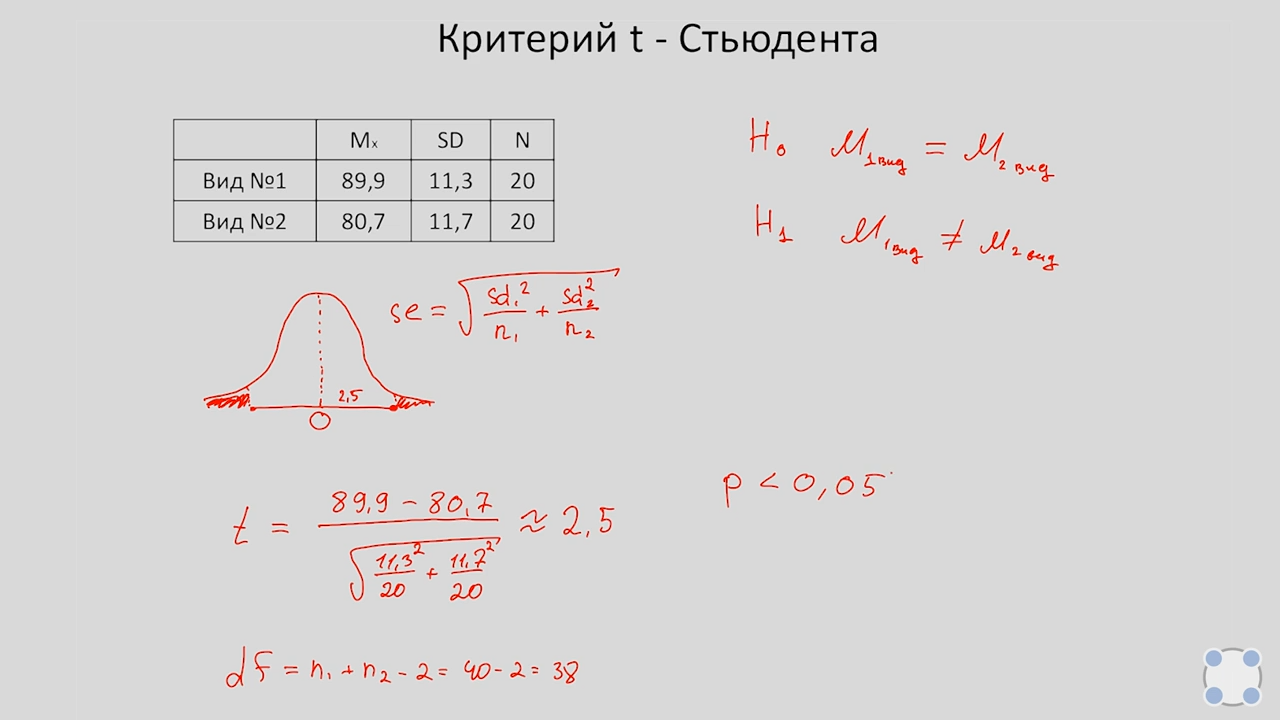

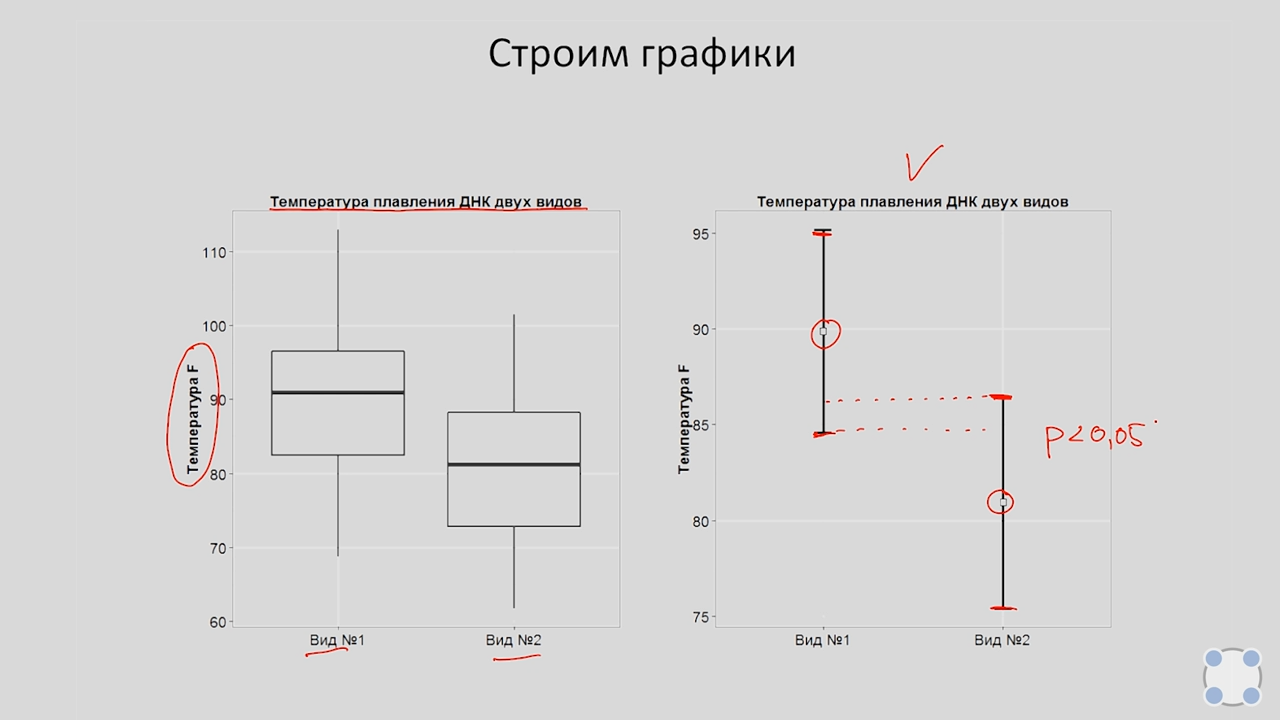

## Пример

In [89]:
sample_1 = [84.7, 105, 98.9, 97.9, 108.7, 81.3, 99.4, 89.4 , 93, 119.3, 99.2, 99.4, 97.1, 112.4, 99.8, 94.7, 114, 95.1, 115.5, 111.5]
sample_2 = [57.2, 68.6, 104.4, 95.1, 89.9, 70.8, 83.5, 60.1, 75.7, 102, 69, 79.6, 68.9, 98.6, 76, 74.8, 56, 55.6, 69.4, 59.5]

N_1 = len(sample_1)
N_2 = len(sample_2)

df_1 = N_1 - 1
df_2 = N_2 - 1

mean_1 = np.mean(sample_1)
mean_2 = np.mean(sample_2)

std_1 = np.std(sample_1)
std_2 = np.std(sample_2)

se = (((std_1**2)/N_1) + ((std_2**2)/N_2))**0.5
t = (mean_1 - mean_2) / se
print(f'N_1 = {N_1}, N_2 = {N_2}')
print(f'mean_1 = {mean_1}, mean_2 = {mean_2}')
print(f'std_1 = {std_1}, std_2 = {std_2}')
print(f'se = {se}')
print(f't = {t}')

df = df_1 + df_2 - 2

p = 2 * (1 - stats.t.cdf(t, df))
if p < 0.05:
    print('p =', p, ', отклоняем нулевую гипотезу. Выборки значимо различаются между собой т.к. p < 0,05')
else:
    print('p =', p, ', нулевую гипотезу отклонить нельзя, т.к. p > 0,05')

N_1 = 20, N_2 = 20
mean_1 = 100.815, mean_2 = 75.73499999999999
std_1 = 9.987055371830078, std_2 = 15.06669422932582
se = 4.041946004092583
t = 6.204931974500849
p = 3.702533857286028e-07 , отклоняем нулевую гипотезу. Выборки значимо различаются между собой т.к. p < 0,05


In [151]:
se_1 = std_1 / N_1 ** 0.05
int_s_1, int_s_2 = mean_1 - stats.t.cdf()
print(int_s_1, int_s_2)

86.67292243857787 114.95707756142212


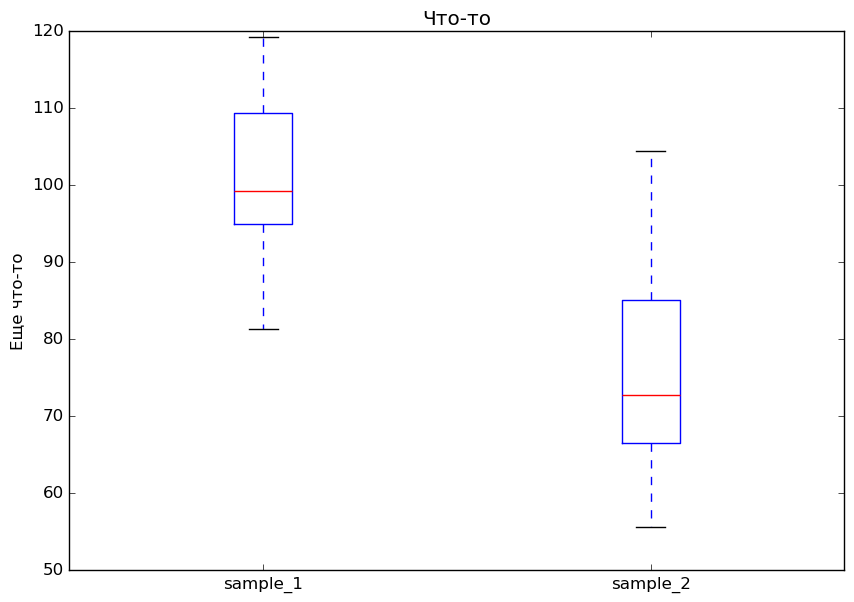

In [133]:
"""Построение графика"""
import matplotlib.pyplot as plt
fig = plt.figure(figsize = (10, 7))
plt.style.use('classic')
plt.boxplot([sample_1, sample_2], tick_labels = ['sample_1', 'sample_2'])
plt.title('Что-то')
plt.ylabel('Еще что-то')
plt.show()

## Пример

In [16]:
M=89.9
sd=11.3
n=20

In [18]:
se = sd / n**0.5
se

2.5267568145747625

In [66]:
t = stats.t.isf(0.025, df = n-1) # находит t или z значение
t

2.0930240544082634

In [64]:
print(M - t*se)
print(M + t*se)

95.43817869263779
84.36182130736222


## Пример

Первые премии Оскар за лучшую мужскую и женскую роль были вручены в 1929. Данные гистограммы демонстрируют распределение возраста победителей с 1929 по 2014 год (100 мужчин, 100 женщин). Используя t - критерий проверьте, можно ли считать наблюдаемые различия в возрасте между лучшими актрисами и актерами  статистически достоверными.
Средний возраст мужчин равен 45, sd = 9.

Средний возраст женщин равен 34, sd = 10.

In [112]:
import math
M_male = 45
std_male = 9
M_female = 34
std_female = 10
N = 100
df = N + N - 2

In [116]:
se = math.sqrt( ((std_male**2)/N) + ((std_female**2)/N) )
se

1.3453624047073711

In [122]:
t = (M_male - M_female)/se
t

8.176235608718828

In [124]:
p = 2 * (1 - stats.t.cdf(t, df))
p

3.441691376337985e-14

# 2.3 Проверка распределения на нормальность, QQ-Plot

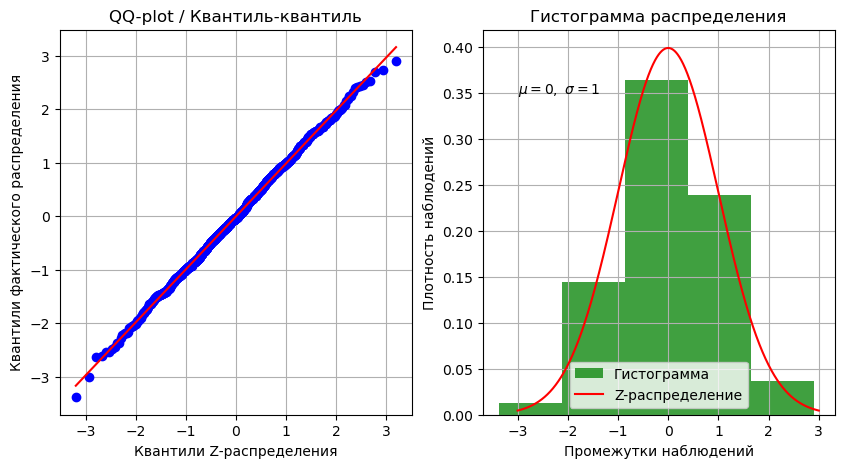

In [198]:
mean = 0
sd = 1
sample = np.random.normal(loc=mean, scale=sd, size=1000)

fig = plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
stats.probplot(sample, dist='norm', plot=plt)  # Создаем график QQ-plot
plt.title('QQ-plot / Квантиль-квантиль')  # Заголовок
plt.xlabel('Квантили Z-распределения')  # Подпись по оси X
plt.ylabel('Квантили фактического распределения')  # Подпись по оси Y
plt.grid(True)  # Включить сетку

plt.subplot(1, 2, 2)
plt.hist(sample, 5, density=True, facecolor='g', alpha=0.75, label='Гистограмма')  # Cтроим гистограмму
plt.title('Гистограмма распределения')  # Заголовок
plt.xlabel('Промежутки наблюдений')  # Подпись по оси X
plt.ylabel('Плотность наблюдений')  # Подпись по оси Y
plt.text(-3, 0.35, r'$\mu=0,\ \sigma=1$')  #Текстовая подпись
plt.grid(True)  # Включить сетку

# Построим поверх гистограммы график Z-распределения
x = np.linspace(mean - 3*sd, mean + 3*sd, 1000)  # Делаем массив значений Z-распределения
plt.plot(x, stats.norm.pdf(x, mean, sd), color='red', label='Z-распределение')  # Строим график Z-распределения

plt.legend()  # Показать легенду

plt.show()

Гистограмма частот с наложенным поверх z-распределением - наглядно показывает отклонение выборочных значений от нормального распределения.

QQ-plot - показывает насколько выборочные значения соответствуют, предсказанным значанием идеально нормального распределения. Пока точки на прямой - идеальное соответствие с нормальным распределением. Если над или под прямой, то значения слишком большие/маленькие соответственно.
Удобно использовать, когда не очень много наблюдений.

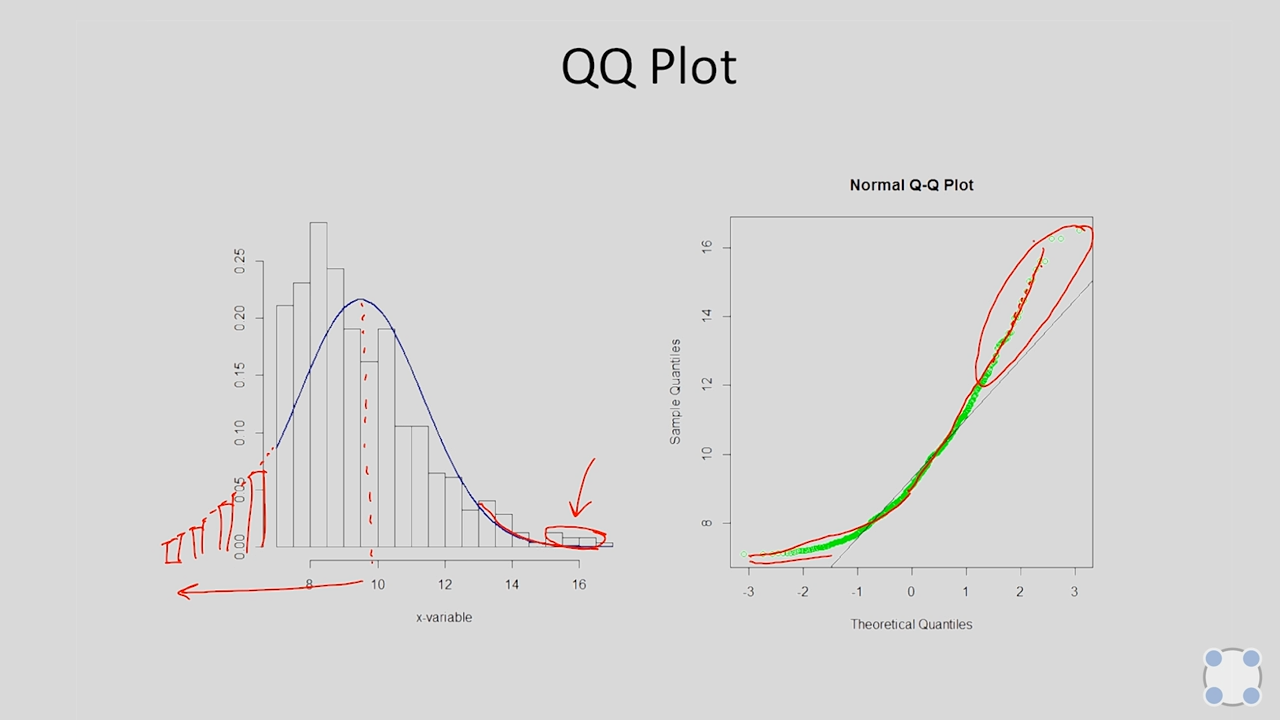

Берём 0.01-квантиль стандартного нормального распределения - это x1 (≈-2.33sd для нормального). Затем берём 0.01-квантиль нашей выборки - это y1. Рисуем на графике точку (x1, y1). Потом берём 0.02-квантиль теоретического распределения - это x2 и 0.02-квантиль выборки - это y2. Рисуем на графике точку (x2, y2). И так далее. Естественно, рисовать точки можно с любым шагом, не только 0.01. Распределения одинаковые, если все эти точки попадут на прямую y=x. Если на другую прямую, то это значит, что распределения одинаковы с точностью до стандартизации. 


Тест Колмогорова-Смирнова

Тест Шапиро-Уилка

### Формулировка H0: 
наши данные значимо не отличаются от нормального, поэтому p > 0.05 не позволяет отклонить нулевую гипотезу

In [218]:
from scipy.stats import shapiro, kstest
import numpy as np

# Doc: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.shapiro.html

array1 = np.array([84.7, 105.0, 98.9, 97.9, 108.7, 81.3, 99.4, 89.4, 93.0,
                   119.3, 99.2, 99.4, 97.1, 112.4, 99.8, 94.7, 114.0, 95.1, 115.5, 111.5])

res_shapiro1 = shapiro(array1)

print(res_shapiro1)

ShapiroResult(statistic=0.9634190949179522, pvalue=0.6141726849030309)


Выбросы - слишком высокие или слишком низкие значения в выборке. Могут оказать значительное влияяние на результаты t-теста.

U-критерий Манна-Уитни - используется для оценки различий между двумя независимыми выборками по уровню какого-либо признака, измеренного количественно. Позволяет выявлять различия в значении параметра между малыми выборками. Переводит измерения в ранговую шкалу. Не так чувствителен к выбросам как t-тест.

# 2.4 Однофакторный дисперсионный анализ

Дисперсионный анализ (Analysis of Variance, ANOVA) - используется когда необходимо сравнить несколько групп между собой(рассмотренный ранее t-критерий Стьюдента предназначен для сравнения только двух совокупностей). Предполагается, что вся изменчивость данных может быть обусловленна 2 показателями:

1. межгрупповым средним квадратом (MSb = SSB/SSB_df);
2. внутригрупповоым средним квадратом (MSw = SSW/SSW_df).

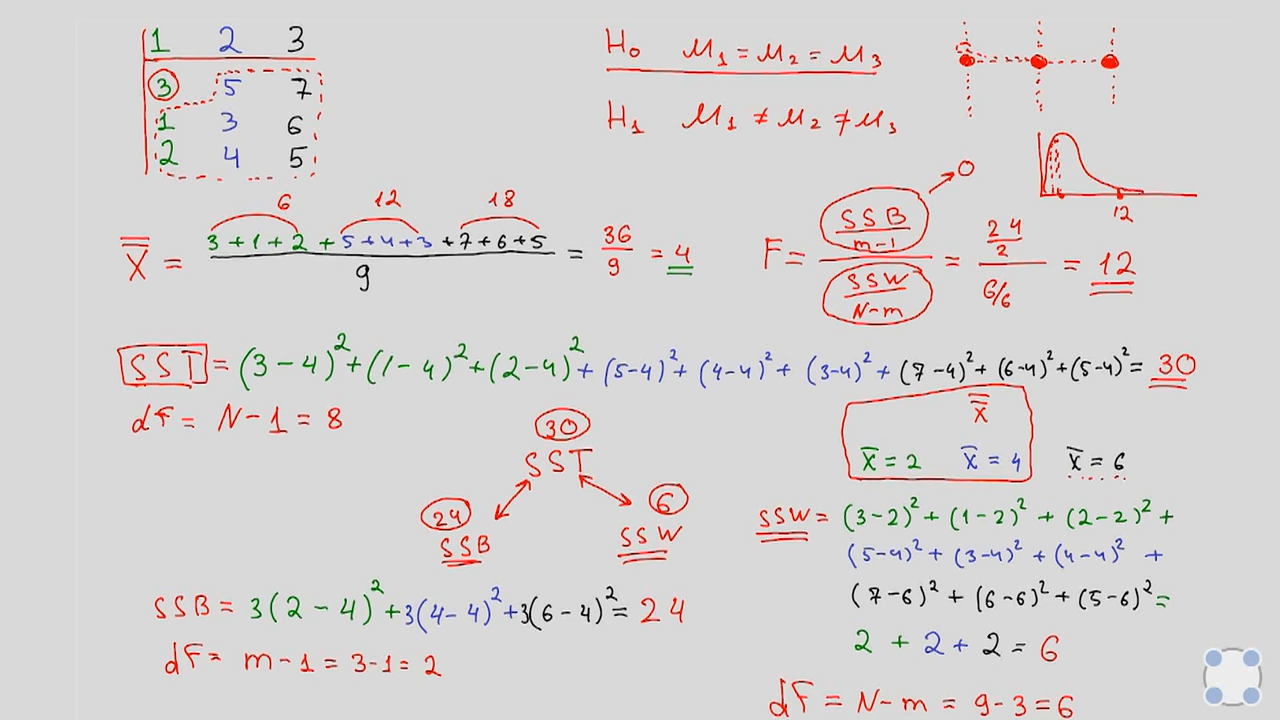

**Общая сумма квадратов (sum of squares total - SST)** - характеризует насколько высока изменчивость данных без учета разделения их на группы. 

SST деленная на число всех наблюдений минус один (SST/SST_df) - это дисперсия, расчитанная для всех наблюдений без учета деления на группы.

SST состоит из двух источников `(SST = SSB + SSW)`:

1. **Межгрупповая сумма квадратов (SSB (between - между) )** - насколько вариативны группы между собой;
2. **Внутригрупповая сумма квадратов (SSW (within- внутри) )** - насколько вариативны значения группы.
Чем больше дисперсия внутри групп, тем больше значение внутригруппового квадрата (при неизменном количестве наблюдений).

F-значение - основной статистический показатель дисперсионного анализа. 
Представляет собой отношение межгрупповой изменчивости к внутригрупповой 

**(F = MSb/MSw)**.

**(MSb = SSB/(кол-во групп (m) - 1))**

**(MSw = SSW/(кол-во наблюдений (N) - кол-во групп (m)))**

### Пример из лекции

In [384]:
URL = 'genetherapy.csv'
df = pd.read_csv(URL)
#df.groupby('Therapy')
df.tail()
#df.groupby('Therapy')
#for groups in df.groupby('Therapy'):
#    print(groups, end='\n\n')

,expr,Therapy
55,87,D
56,93,D
57,96,D
58,92,D
59,90,D


### ANOVA через f-oneway

In [402]:
from scipy.stats import f_oneway
group_1 = df[df['Therapy'] == 'A']['expr']
group_2 = df[df['Therapy'] == 'B']['expr']
group_3 = df[df['Therapy'] == 'C']['expr']
group_4 = df[df['Therapy'] == 'D']['expr']
F, p = stats.f_oneway(group_1, group_2, group_3, group_4)
print(f'Значение F равно {round(F, 5)}, p-value равно {round(p, 5)}, следовательно, отклоняем нулевую гипотезу')

Значение F равно 8.0373, p-value равно 0.00015, следовательно, отклоняем нулевую гипотезу


### ANOVA как в R

In [418]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols

rehab_lm = ols('expr ~ C(Therapy)', data=df).fit()
sm.stats.anova_lm(rehab_lm)

,df,sum_sq,mean_sq,F,PR(>F)
C(Therapy),3.0,560.716667,186.905556,8.037302,0.000152
Residual,56.0,1302.266667,23.254762,NaN,NaN


### График boxplot для ANOVA

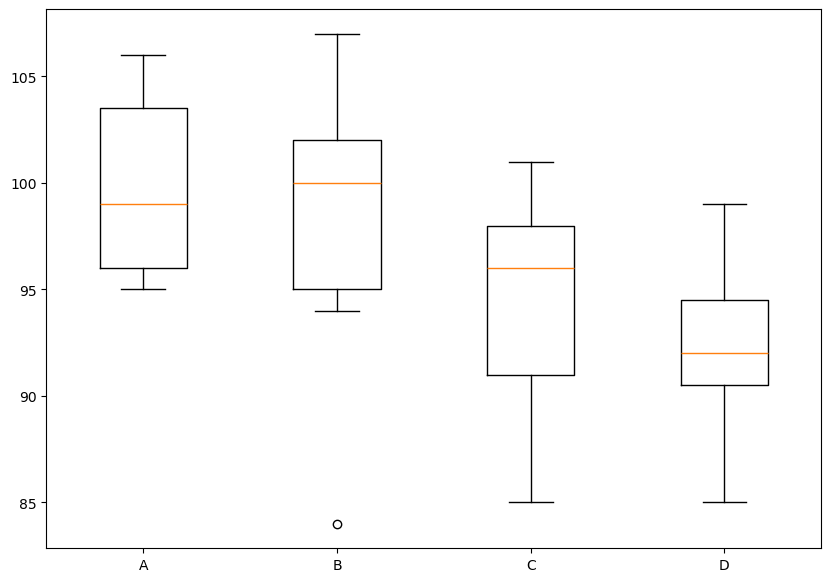

In [434]:
fig = plt.figure(figsize=(10, 7))
plt.boxplot([group_1, group_2, group_3, group_4], tick_labels = ['A', 'B', 'C', 'D'])
plt.show()

In [446]:
A = df.loc[df['Therapy']== 'A', 'expr'].values
B = df.loc[df['Therapy']== 'B', 'expr'].values
B

array([100, 100,  95,  84, 101, 101,  95, 106, 105,  97, 103,  94,  94,
       100, 107], dtype=int64)

### График доверительных интервалов для ANOVA

<Axes: xlabel='Therapy', ylabel='expr'>

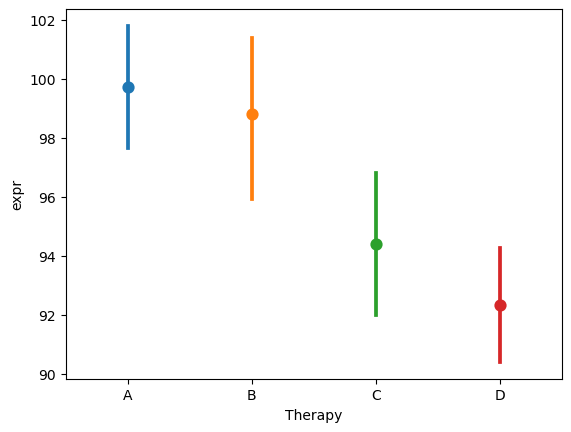

In [455]:
import seaborn as sns
sns.pointplot(x='Therapy', y='expr', hue = 'Therapy', data=df)

A 99.73333333333333 4.1656189158852435
B 98.8 5.894307180904058
C 94.4 5.193402408000807
D 92.33333333333333 3.7352886036263593


C:\Users\ryagu\AppData\Local\Temp\ipykernel_3176\4202562900.py:12: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  plt.errorbar(x=listName, y=listMEAN, yerr=listERR, color='black', capsize=3,


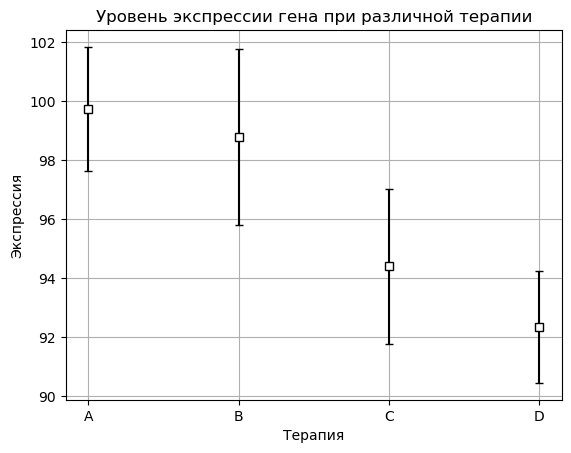

In [459]:
import math
listName = []
listMEAN = []
listERR = []

for group, frame in df.groupby('Therapy')['expr']:
    print(group, frame.mean(), frame.std())
    listName.append(group)
    listMEAN.append(frame.mean())
    listERR.append(1.96*frame.std()/math.sqrt(15))

plt.errorbar(x=listName, y=listMEAN, yerr=listERR, color='black', capsize=3,
             marker='s', markersize=6, mfc='white',mec='black', fmt='o')
plt.title('Уровень экспрессии гена при различной терапии')
plt.grid()
plt.xlabel('Терапия')
plt.ylabel('Экспрессия')
plt.show()

# 2.5 Множественные сравнения в ANOVA

Получается, когда мы просто делаем однофакторный ANOVA, мы можем узнать есть ли вообще какие-то значимые отличия (как минимум между двумя группами). Но чтобы понять какие именно группы отличаются между собой, нам уже нужно делать попарное сравнение. И тут нужно будет использовать поправку на множественные сравнения.

Если мы многократно увеличиваем количество групп, которые будут участвовать в нашем исследовании и которые мы будем сравнивать между собой, то вероятность получить хотя бы одно значимое различие, которое на самом деле не существует, очень сильно увеличивается и стремится к единице.

Для вычисления попарных сравнений используется формула: **(m(число групп) * (m-1))/2**

## Поправка Бонферрони
**Поправка Бонферрони** - относится к процессу корректировки **уровня альфа(α)**  статистических тестов таким образом, чтобы контролировать вероятность совершения ошибки I рода.  
Если необходимо удержать вероятность совершения ошибки I рода на уровне 0.05, то нужно разделить **α** на **количество сравнений, которые нужно будет провести(N_comp)**.  
**α_new = α / N_comp**  
где N_comp - количество сравнений между группами выборок.  

*Например:* сравниваются 8 групп между собой, тогда количество сравнений - 8 * (8-1) / 2 = 28.  α_new = 0.05 / 28 = 0.0017.  

**Почему не любят поправку Бонферрони:** Поправка Бонферрони делает настолько низкий p, при большом количестве сравнений, что получить значимые различия становится очень сложно. В то время как в современной статистике вычисления при большом количестве выборок происходит повсеместно.

## Критерий Тьюки(Tukey HSD) 
**Критерий Тьюки(Tukey HSD)** - представляет собой модифицированный критерий Стьюдента.

Критерий Тьюки имеет те же условия применимости, что и дисперсионный анализ, т.е. нормальность распределения данных и однородность групповых дисперсий. Устойчивость к отклонению от этих условий, как и статистическая мощность критерия Тьюки, возрастают при одинаковом числе наблюдений во всех сравниваемых группах.  

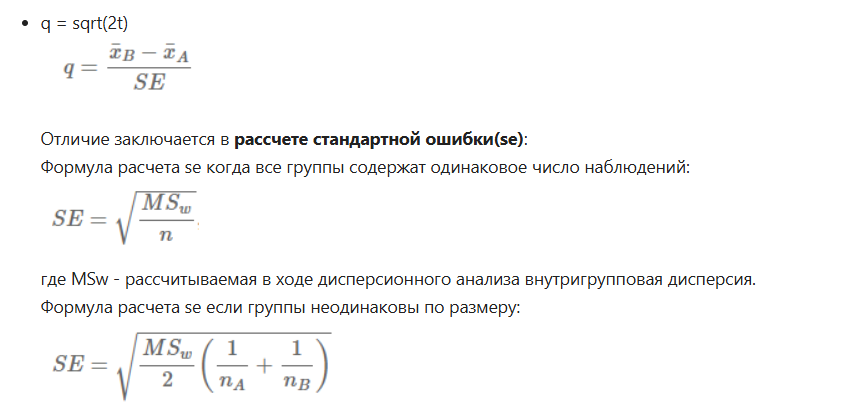

**Т.е. рассчитывается доверительный интервал для разницы средних значений сравниваемых групп. Если доверительный интервал не включает ноль, то различия значимы. Также сомтрим на p-value. Если p-value меньше 0.05, то различия значимы**

H0 - это гипотеза, что распределения А и В совпадают, а значит совпадают и их средние, то есть, Xa = Xb. Следовательно, Xa - Xb = 0.

Если мы получили, что доверительный интервал для Xa - Xb не содержит 0, то мы на самом деле получили, что с 95% вероятностью Xa - Xb не равно 0 ---> Xa не равно Xb. То есть средние распределений не равны, а значит, распределения А и B разные, что отклоняет нулевую гипотезу 

## Код для Критерия Тьюки

In [497]:
URL = 'genetherapy.csv'
df = pd.read_csv(URL)
df.head()

,expr,Therapy
0,100,A
1,96,A
2,101,A
3,95,A
4,103,A


In [502]:
from statsmodels.sandbox.stats.multicomp import MultiComparison
MultiComp = MultiComparison(df['expr'], df['Therapy'])

print(MultiComp.tukeyhsd().summary())

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
     A      B  -0.9333 0.9514  -5.5959  3.7292  False
     A      C  -5.3333 0.0189  -9.9959 -0.6708   True
     A      D     -7.4 0.0005 -12.0626 -2.7374   True
     B      C     -4.4  0.071  -9.0626  0.2626  False
     B      D  -6.4667 0.0029 -11.1292 -1.8041   True
     C      D  -2.0667 0.6458  -6.7292  2.5959  False
-----------------------------------------------------


In [504]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
tukey = pairwise_tukeyhsd (endog=df['expr'], groups=df['Therapy'], alpha=0.05)
print(tukey)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
     A      B  -0.9333 0.9514  -5.5959  3.7292  False
     A      C  -5.3333 0.0189  -9.9959 -0.6708   True
     A      D     -7.4 0.0005 -12.0626 -2.7374   True
     B      C     -4.4  0.071  -9.0626  0.2626  False
     B      D  -6.4667 0.0029 -11.1292 -1.8041   True
     C      D  -2.0667 0.6458  -6.7292  2.5959  False
-----------------------------------------------------


In [508]:
0.05/3

0.016666666666666666

# 2.6 Многофакторный ANOVA

**Двухфакторный дисперсионный анализ** - это статистический метод, используемый для анализа данных, которые имеют **два фактора**, которые могут влиять на зависимую переменную. Данный метод позволяет определить, как каждый из двух факторов влияет на зависимую переменную, а также как взаимодействие между двумя факторами может влиять на зависимую переменную.  

Основная идея сводится к тому, что **общая изменчивость(SStotal)** состоит из суммы четырех компонентов: внутригрупповая изменчивость(SSW), изменчивость под влиянием фактора A(SSBa), изменчивость под влиянием фактора B(SSBb) и изменчивость, обусловленная взаимодействием этих двух факторов(SSBa * SSBb).  
**SStotal = SSW + SSBa + SSBb + SSBa * SSBb**  

*Например: в экономике двухфакторный дисперсионный анализ может использоваться для определения, как два фактора, такие как цена и рекламный бюджет, влияют на продажи определенного товара.*  

**Взаимодействие факторов** - ознчает, что влияние одного фактора по-разному проявляется на зависимую переменную в зависимости от градаций другого фактора.  

**Причиной отклонения H0** в многофакторном дисперсионном анализе могут быть:  
* Значимый эффект для всех факторов;  
* Значимый эффект одного из фактора;  
* Значимое взаимодействие факторов.

**Требования к данным** в дисперсионном анализе:  
1) Нормальность распределения зависимой переменной в каждой из групп;  
2) Гомогенность дисперсии (примерно одинаковая дисперсия в каждой из групп).  

Чем больше наблюдений (N>50), тем более устойчива ANOVA к нарушениям этих требований.
Нормальность можно проверить с помощью QQ-plot, наличие выбросов с помощью box-plot, гомогенность с помощью Levene's Test.

## Пример

In [706]:
"""Атеросклероз довольно опасное заболевание - причина ишемической болезни сердца и инсультов.
   Анализ экспрессии генов лейкоцитов позволяет предсказать вероятность развития данного заболевания.
   В эксперименте исследовался уровень экспрессии в зависимости от возраста пациентов и дозировки лекарства аторвастатина."""

URL = 'https://stepik.org/media/attachments/lesson/9250/atherosclerosis.csv'

df = pd.read_csv(URL, header=0, sep=',')
df.head()

,expr,age,dose
0,107.351478,1,D1
1,104.504438,1,D1
2,103.435134,1,D1
3,109.572882,1,D1
4,114.993803,1,D1


## Многофакторный ANOVA с помощью statsmodels

In [709]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols

model = ols('expr ~ C(dose)*C(age)', df).fit()
res = sm.stats.anova_lm(model, typ=2)
res 
# Residual - внутригрупповая изменчивость

,sum_sq,df,F,PR(>F)
C(dose),16.912241,1.0,0.638094,0.427552
C(age),197.452754,1.0,7.449841,0.008313
C(dose):C(age),0.927077,1.0,0.034978,0.852272
Residual,1590.257424,60.0,NaN,NaN


## График доверительных интервалов для ANOVA

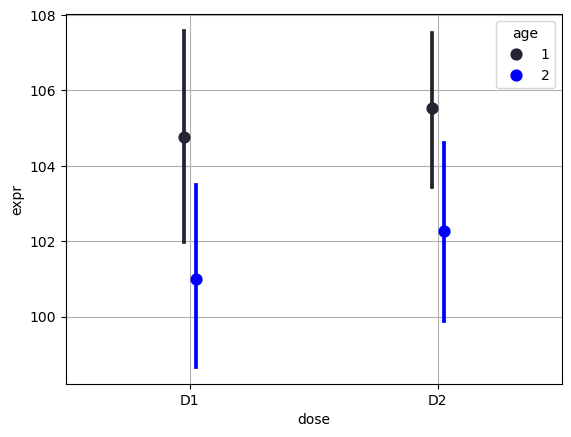

In [718]:
"""Визуализация seaborn"""
import seaborn as sns

sns.pointplot(x = df.dose, y = df.expr,
              hue = df.age, data = df,
              dodge = True, linestyles=['', ''], palette='dark:blue')
plt.grid()

## Критерий Тьюки(Tukey HSD) 

In [573]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
tukey = pairwise_tukeyhsd (endog=df['expr'], groups=df['age'].apply(str) + "_" + df['dose'], alpha=0.05) # 4 группы сравниваются, т.е. 6 попарных сравнений
print(tukey)

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
  1_D1   1_D2   0.7874 0.9726 -4.0225 5.5973  False
  1_D1   2_D1  -3.7537 0.1774 -8.5635 1.0562  False
  1_D1   2_D2  -2.4848 0.5259 -7.2947  2.325  False
  1_D2   2_D1  -4.5411  0.071 -9.3509 0.2688  False
  1_D2   2_D2  -3.2722 0.2845 -8.0821 1.5376  False
  2_D1   2_D2   1.2688 0.8978  -3.541 6.0787  False
---------------------------------------------------


In [579]:
df['group'] = df['age'].apply(str) + "_" + df['dose']
df.head()

,expr,age,dose,group
0,107.351478,1,D1,1_D1
1,104.504438,1,D1,1_D1
2,103.435134,1,D1,1_D1
3,109.572882,1,D1,1_D1
4,114.993803,1,D1,1_D1


## График Критерия Тьюки

<ErrorbarContainer object of 3 artists>

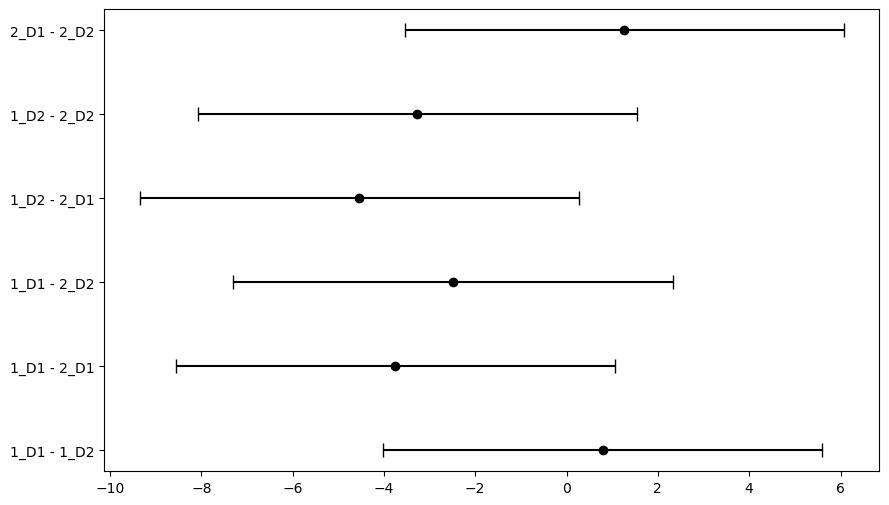

In [622]:
tukey_df = pd.DataFrame(
    data=tukey._results_table.data[1:],
    columns=tukey._results_table.data[0]
)

# График
plt.figure(figsize=(10, 6))
plt.errorbar(
    y=tukey_df['group1']+ ' - ' +tukey_df['group2'],
    x=tukey_df['meandiff'],
    xerr=[tukey_df['meandiff'] - tukey_df['lower'], tukey_df['upper'] - tukey_df['meandiff']],
    fmt='o',
    capsize=5,
    color='black'
)

## Пример

In [722]:
URL = 'https://stepik.org/media/attachments/lesson/9250/birds.csv'
df = pd.read_csv(URL)
df.head()

,var4,hormone,sex
0,17.859039,1,1
1,20.842343,1,1
2,19.318099,1,1
3,20.064451,1,1
4,17.620316,1,1


In [724]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols

model = ols('var4 ~ C(hormone)*C(sex)', df).fit()
res = sm.stats.anova_lm(model, typ=2)
res 
# Residual - внутригрупповая изменчивость

,sum_sq,df,F,PR(>F)
C(hormone),0.847472,1.0,0.086528,0.769653
C(sex),0.119762,1.0,0.012228,0.912318
C(hormone):C(sex),89.483384,1.0,9.136390,0.003682
Residual,587.650394,60.0,NaN,NaN


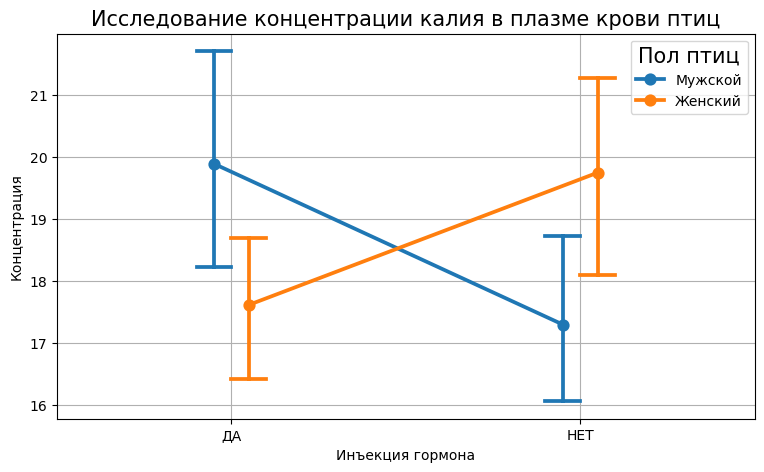

In [730]:
fig = plt.figure(figsize=(9,5))
pplot = sns.pointplot(x = df.hormone, y = df.var4,
                      hue = df.sex, data = df,
                      dodge = 0.1, capsize=.1)

plt.xticks([0, 1], ['ДА', 'НЕТ'], fontsize=10)

# заголовки графика и осей
plt.title('Исследование концентрации калия в плазме крови птиц', fontsize=15)
plt.xlabel('Инъекция гормона', fontsize=10)
plt.ylabel('Концентрация', fontsize=10)

# легенда
leg_handles = pplot.get_legend_handles_labels()[0]
pplot.legend(leg_handles, ['Мужской', 'Женский'], title='Пол птиц', title_fontsize=15, fontsize=10, loc = 'upper right')

plt.grid()

**Заметка: если линии на графике параллельны, то совместного взаимодействия факторов нет**

## Проверка на нормальность 

In [736]:
df.head()

,var4,hormone,sex
0,17.859039,1,1
1,20.842343,1,1
2,19.318099,1,1
3,20.064451,1,1
4,17.620316,1,1


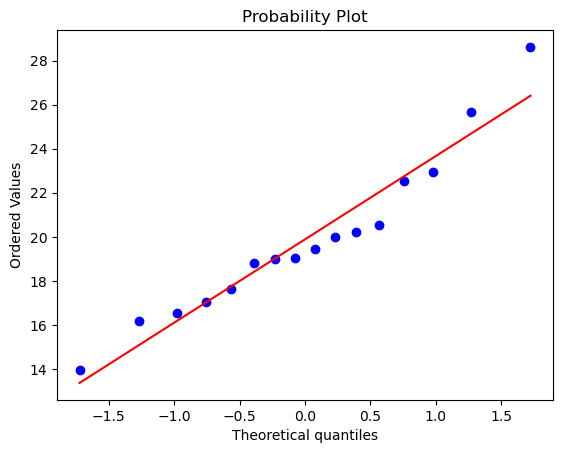

ShapiroResult(statistic=0.9451041792618118, pvalue=0.41628950975672196)


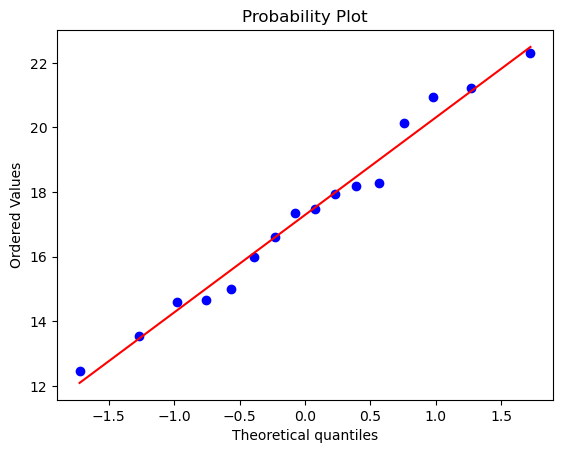

ShapiroResult(statistic=0.9721518243206879, pvalue=0.872145447346442)


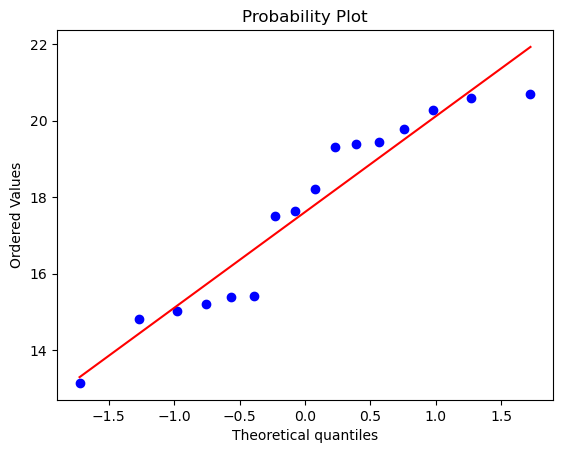

ShapiroResult(statistic=0.9067473755208632, pvalue=0.10314326182110384)


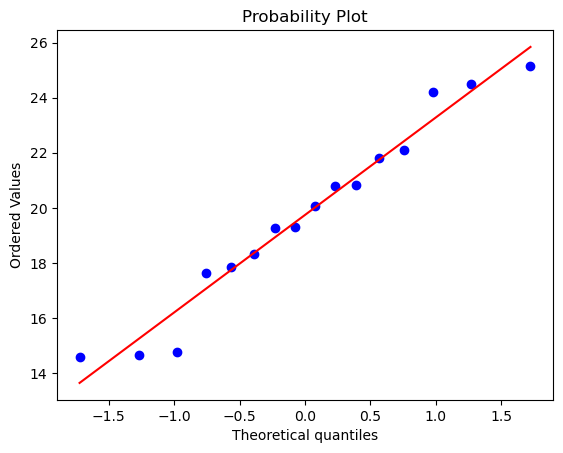

ShapiroResult(statistic=0.9481916432878276, pvalue=0.46159299650540697)


In [748]:
from scipy.stats import shapiro, probplot
import pylab

x1 = df[(df["sex"] == 0) & (df["hormone"] == 0)]["var4"].values
x2 = df[(df["sex"] == 0) & (df["hormone"] == 1)]["var4"].values
x3 = df[(df["sex"] == 1) & (df["hormone"] == 0)]["var4"].values
x4 = df[(df["sex"] == 1) & (df["hormone"] == 1)]["var4"].values
lst = [x1, x2, x3, x4]
for i in lst:
    stats.probplot(i, dist="norm", plot=pylab)
    plt.show()
    print(shapiro(i))

# shapiro - проверяет на нормальность распределения, если p >0.05, то нулеая гипотеза не отклоняется.
# H0: «Анализируемая выборка происходит из генеральной совокупности, имеющей нормальное распределение».

# 2.7 АБ тесты и статистика

АБ тестирование - это проведение экспериментов при помощи статистики, пожалуй, самый яркий пример того, зачем статистика нужна в реальной жизни!) A/B тесты - один из основных инструментов в продуктовой аналитике. Этот метод маркетингового исследования заключается в том, что контрольная группа элементов сравнивается с набором тестовых групп, где один или несколько показателей изменены для того, чтобы выяснить, какие из изменений улучшают целевой показатель. Например, мы можем поменять цвет кнопки для регистрации с красного на синий и сравнить, насколько это будет эффективно. 